<img src="https://github.com/CharleyHananiaGA/DSB-Unit-02/blob/main/assets/ga-logo.png?raw=1" style="float: left; margin: 20px; height: 55px">

# Visualizing relationships

---

### About
Understand how to create charts within `pandas` using the `.plot()` method.

### Learning Objectives
- Apply appropriate chart types when exploring a data set.
- Explore patterns and relationships in data with bar charts and scatter plots.


### Notebook Guide
- Scenario
- Getting started with plotting in `pandas`
    - Bar charts
    - Scatter plots
- Now You Try!
- Conclusions and Takeaways

# Scenario

You're an analyst working for CoolBricks - a new toy company who wants to compete with LEGO by producing their own bricks and sets. To better understand what kind of sets to create and at what price points, you are tasked with analyzing LEGO's catalogue over time.

The data comes from Kaggle: [https://www.kaggle.com/datasets/alexracape/lego-sets-and-prices-over-time](https://www.kaggle.com/datasets/alexracape/lego-sets-and-prices-over-time)

We are going to use `pandas` to read this data and `matplotlib` to create plots.

## What is `matplotlib`?

- A visualization library (its name comes from MATLAB, plot, and library)
- The most universally used data visualization library for Python
- Tightly coupled with `pandas`, and `pandas` plots use `matplotlib` under the hood
- Can be used directly to fully control visualizations (in this notebook we will access it via the `pandas` `.plot()` method

# Getting started with plotting in `pandas`
---

In [1]:
import pandas as pd

Let's look at the data.

In [2]:
lego_df = pd.read_csv("https://raw.githubusercontent.com/CharleyHananiaGA/DSB-Unit-02/refs/heads/main/data/lego.csv")
lego_df.head()

,Set_ID,Name,Year,Theme,Theme_Group,Subtheme,Category,Packaging,Num_Instructions,Availability,Pieces,Minifigures,Owned,Rating,USD_MSRP,Total_Quantity,Current_Price
0,75-1,PreSchool Set,1975,PreSchool,Pre-school,NaN,Normal,{Not specified},0,{Not specified},16.0,NaN,10.0,0.0,NaN,NaN,NaN
1,77-1,PreSchool Set,1975,PreSchool,Pre-school,NaN,Normal,{Not specified},0,{Not specified},20.0,NaN,11.0,0.0,NaN,NaN,NaN
2,077-1,Pre-School Set,1975,Duplo,Pre-school,NaN,Normal,{Not specified},0,{Not specified},21.0,NaN,10.0,0.0,NaN,0.0,NaN
3,78-1,PreSchool Set,1975,PreSchool,Pre-school,NaN,Normal,{Not specified},0,{Not specified},32.0,NaN,8.0,0.0,NaN,NaN,NaN
4,78-3,Basic Set,1975,Samsonite,Vintage,Basic set,Normal,Box,0,{Not specified},330.0,NaN,10.0,0.0,NaN,0.0,NaN


One common way to create plots is on a `pandas` DataFrame directly.

<Axes: >

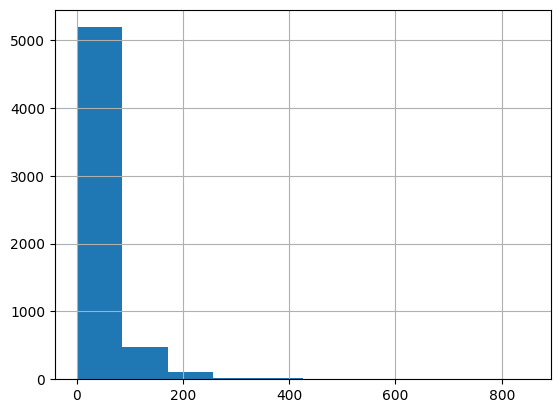

In [8]:
lego_df["USD_MSRP"].hist()

When we run any `matplotlib`, the output will not only be a graph but also some text which is not formatted well.  To exclude the text, add a semicolon `;` to the end of the last line of code.

### Working with `matplotlib` in `pandas`

- For plots that require a *single* column of data (e.g. histograms), the plotting function (e.g. `.hist()`) is typically on the `Series`
- For plots whose underlying data requires *multiple* columns (e.g. scatter plots), the plotting function (e.g. `.plot()`) is typically on the `DataFrame`

Often, the best way to visualize data in Python is to:

- Transform the data into the appropriate shape
- Call a single function (usually `.plot()`)

***Note: for quick visualizations, we use `pandas` without even referencing `matplotlib` explicitly!***

## Bar charts

Let's say we want to visualize the **average price of a set for each theme group**

We can calculate this with a `.groupby()`

In [12]:
lego_df.groupby("Theme_Group")["USD_MSRP"].median().sort_values(ascending=False)

,USD_MSRP
Theme_Group,
Educational,102.45
Technical,49.99
Model making,39.99
Licensed,29.99
Modern day,29.99
Action/Adventure,24.99
Pre-school,24.99
Girls,22.99
Junior,19.99


In [15]:
group_price = lego_df.groupby("Theme_Group")["USD_MSRP"].median().sort_values(ascending=False)

In [14]:
group_price

,USD_MSRP
Theme_Group,
Educational,102.45
Technical,49.99
Model making,39.99
Licensed,29.99
Modern day,29.99
Action/Adventure,24.99
Pre-school,24.99
Girls,22.99
Junior,19.99


This is fine, it answers our question, but it would be easier to compare groups visually.

Let's remove the `Vintage` category from our results since there aren't any price values for that category (which we know because there's a `NaN` where an average price should be).

In [24]:
group_prices = (
    lego_df.groupby("Theme_Group")["USD_MSRP"]
    .median()
    .dropna()  # remove any average prices that are actually missing
    # .sort_values(ascending=False)
)


Now that we have the data in the right shape (in this case a `Series` with the index as the labels and the values as the result of the calculation) we only need a plotting function!

<Axes: xlabel='Theme_Group'>

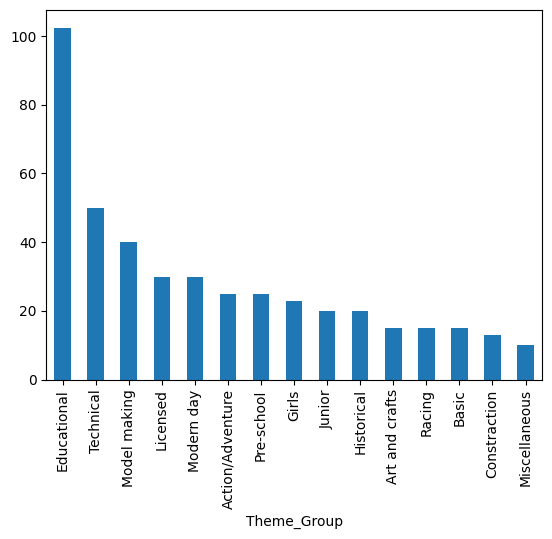

In [18]:
group_prices.plot(kind="bar")

This might look better as a horizontal bar chart.

Just change the plot "kind"!

<Axes: ylabel='Theme_Group'>

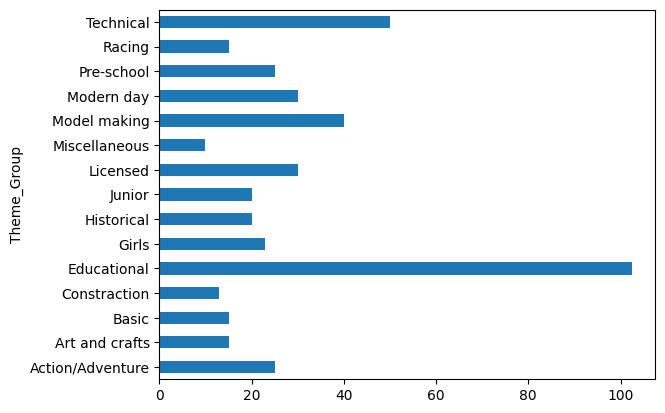

In [25]:
group_prices.plot(kind="barh")

Note: for horizontal bar charts, data is presented from **the x-axis upwards** so if you want the bars to be in *descending* order, the data needs to be in *ascending* order

We can change some options too.

<Axes: title={'center': "Sets categorised as 'Education' are the most expensive on average"}, xlabel='Median retail price ($)', ylabel='Theme Group'>

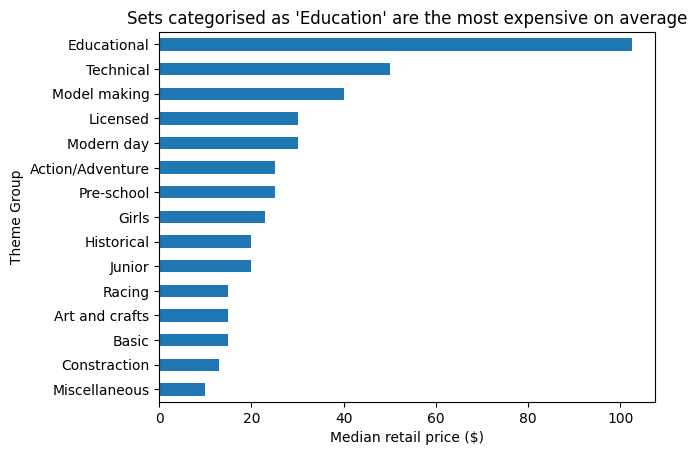

In [27]:
group_prices.sort_values().plot(
     kind="barh"
    ,title="Sets categorised as 'Education' are the most expensive on average"
    ,xlabel="Median retail price ($)"
    ,ylabel="Theme Group"
    )


## Scatter plots

Let's find out if there is a link between a set's recommended retail price and its current retail price.

For scatter plots, we usually see *raw* data, not aggregations. This is why the plot function is called on the `DataFrame` directly.

<Axes: xlabel='USD_MSRP', ylabel='Current_Price'>

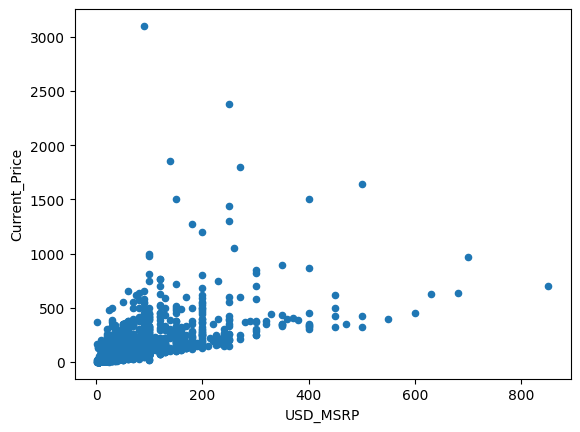

In [31]:
lego_df.plot(kind="scatter", x="USD_MSRP", y="Current_Price")

Looks like most sets can currently be bought at a similar price to the retail price with some outliers in both directions.

To make the "overplotting" effect less prominent (where lots of points make a dense area) we can alter the transparency of points.

Let's also get into the habit of changing some options.

<Axes: title={'center': 'Most sets still sell at their retail price,with some outliers'}, xlabel='Recommended Retail price ($)', ylabel='Current price on the market ($)'>

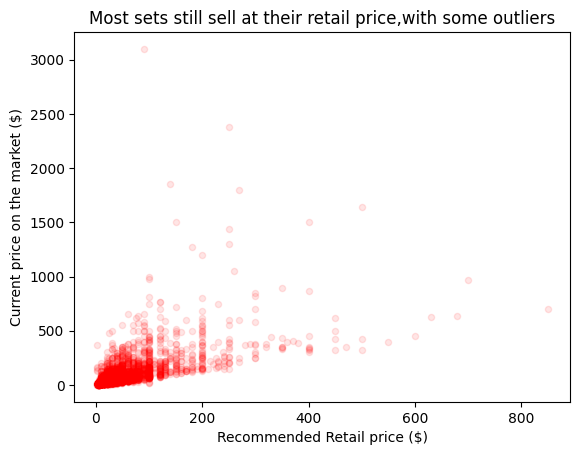

In [36]:
lego_df.plot(
     kind="scatter"
    ,x="USD_MSRP"
    ,y="Current_Price"
    ,title="Most sets still sell at their retail price,with some outliers"
    ,xlabel="Recommended Retail price ($)"
    ,ylabel="Current price on the market ($)"
    ,alpha=0.1
    ,color="red"
    )

# Now You Try!
---

1. Calculate and visualize the *biggest* set (in terms of number of pieces) per theme group with a bar chart. Bonus: can you change the color of the bars?

<Axes: title={'center': "The biggest set is nearly 12,000 pieces and is in the 'Art and crafts' category"}, xlabel='Number of pieces in the biggest set within a group', ylabel='Theme group'>

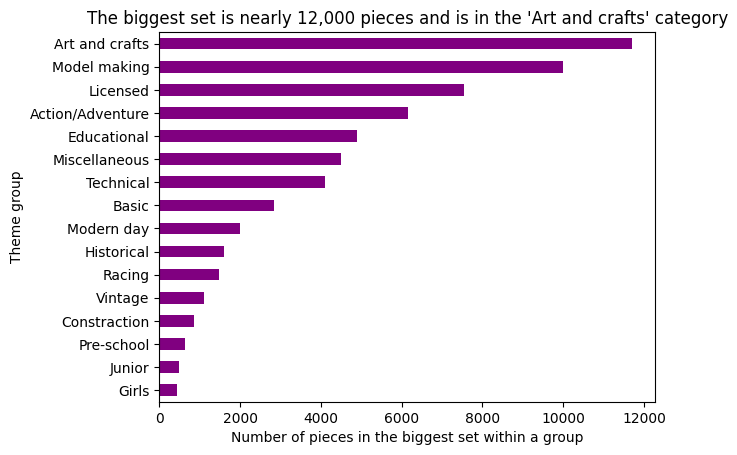

In [47]:
lego_df.groupby("Theme_Group")["Pieces"].max().sort_values().plot(
       kind="barh"
      ,title="The biggest set is nearly 12,000 pieces and is in the 'Art and crafts' category"
      ,xlabel="Number of pieces in the biggest set within a group"
      ,ylabel="Theme group"
      ,color="purple")

2. Create a scatter plot to visualize the number of pieces versus the recommended retail price. Is there a relationship? Change any options in the plot you see fit.

<Axes: xlabel='Number of pieces', ylabel='Recommended Retail Price ($)'>

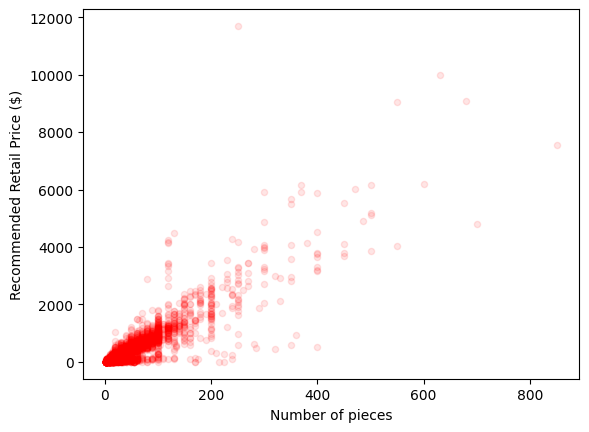

In [49]:
lego_df.plot(
     kind="scatter"
    ,x="USD_MSRP"
    ,y="Pieces"
    ,title="Generally, the more pieces a set has the mote expensive it is"
    ,xlabel="Number of pieces"
    ,ylabel="Recommended Retail Price ($)"
    ,alpha=0.1
    ,color="red"
    )

# Conclusions and Takeaways

- `pandas` lets us create visualizations directly from the data
- In `pandas`, plots are created with `matplotlib` under the hood
- For simple plots, we can use `pandas` methods without referencing `matplotlib` directly